# Контрольная классификация SRNet: Cats vs Dogs (grayscale, 256×256) — V02

## Цель

Верификация обучаемости архитектуры SRNet на задаче семантической классификации
(серия 1 ВКР) перед применением к стеганоанализу (серии 2–3).

## Описание эксперимента

Ноутбук реализует контрольную классификацию «кошки vs собаки» на архитектуре SRNet  — верификацию обучаемости модели на семантической задаче (серия 1 ВКР) перед применением к стеганоанализу в сериях 2–3.

SRNet (Boroumand et al., 2019) отличается от остальных архитектур проекта двухуровневой системой остаточных блоков. 8 Type-I блоков обрабатывают изображение в полном разрешении 256×256 без пулинга — каналы остаются неизменными (64), а пространственные размеры сохраняются. Затем 4 Type-II блока со stride=2 последовательно понижают разрешение (256→128→64→32→16) и наращивают каналы (64→128→256→512). Для стеганоанализа обработка в полном разрешении критична: LSB-сигнал (±1 в младшем бите) имеет пространственную структуру, которая разрушается при раннем пулинге. Для семантической классификации эта архитектурная особенность, напротив, избыточна — высокоуровневые признаки формы и текстуры эффективнее формируются при раннем понижении разрешения.


Датасет — Kaggle Cats vs Dogs: 1999 grayscale-изображений 256×256 (999 кошек, 1000 собак), разбиение holdout 70/15/15. Аугментации — горизонтальное и вертикальное отражение. Обучение: Adam + CosineAnnealingLR (1e-3 → 1e-5), CrossEntropyLoss, gradient clipping (max_norm=1.0), 35 эпох, seed=42.

## Конфигурация эксперимента (серия 1)

| Параметр | Значение |
|---|---|
| **Архитектура** | SRNet (8 Type-I + 4 Type-II, Boroumand et al. 2019) |
| **Входные данные** | Grayscale, 256×256, 1 канал |
| **Датасет** | Cats-vs-Dogs-Gray: Cat≈1000, Dog≈1000 |
| **Разбиение** | Holdout: Train 70% / Val 15% / Test 15% |
| **Batch size** | 32 |
| **Learning rate** | 1e-3 → 1e-5 (CosineAnnealingLR) |
| **Эпох** | 35 |
| **HPF** | Обучаемый (Kaiming init) + BN + ReLU |
| **Оптимизатор** | Adam, weight_decay=1e-4 |
| **Loss** | CrossEntropyLoss |
| **Dropout** | Dropout(0.3) перед FC |
| **Grad clipping** | max_norm=1.0 |

In [1]:
# Монтирование Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1. Импорт библиотек и глобальные настройки

import os
import json
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [3]:
# 2. Глобальные настройки

# Фиксация seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Константы
IMAGE_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 35
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Пути
DATASET_PATH = "/content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000"
SAVE_DIR = "/content/drive/MyDrive/FQW/cat-dog_srnet_256_V02"
os.makedirs(SAVE_DIR, exist_ok=True)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Память: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Устройство: cuda
GPU: NVIDIA A100-SXM4-40GB
Память: 42.41 GB


In [4]:
# 3. Загрузка и анализ датасета

dataset_root = Path(DATASET_PATH)
print(f"Сканирование: {dataset_root}")

data = []
for label_name, label_num in [("cat", 0), ("dog", 1)]:
    folder = dataset_root / label_name
    if folder.exists():
        for img_path in sorted(folder.glob("*.*")):
            if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                data.append({
                    "path": str(img_path),
                    "label": label_name,
                    "label_num": label_num,
                    "filename": img_path.name,
                })
        count = len([d for d in data if d["label"] == label_name])
        print(f"  {label_name}: {count}")
    else:
        print(f"  Папка не найдена: {folder}")

df = pd.DataFrame(data)
print(f"\nВсего изображений: {len(df)}")
print(f"Баланс классов:")
print(df["label"].value_counts())

# Разделение: 70 / 15 / 15
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED
)

print(f"\nРазделение:")
print(f"  Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

Сканирование: /content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000
  cat: 999
  dog: 1000

Всего изображений: 1999
Баланс классов:
label
dog    1000
cat     999
Name: count, dtype: int64

Разделение:
  Train: 1399 (70.0%)
  Val:   300 (15.0%)
  Test:  300 (15.0%)


In [5]:
# 4. АРХИТЕКТУРА SRNet (контрольная классификация)
#
# Оригинальная структура Boroumand et al., 2019:
#   HPF (1→64) + BN + ReLU
#   8× Type-I блоков (64 каналов, без пулинга — полное разрешение)
#   Type-II (64→128,  stride=2)  256→128
#   Type-II (128→256, stride=2)  128→64
#   Type-II (256→512, stride=2)  64→32
#   Type-II (512→512, stride=2)  32→16
#   GAP → Dropout(0.3) → FC(512, 2)
#
# Для контрольной задачи: HPF обучаемый + ReLU (без Tanh+Abs).


class TypeIBlock(nn.Module):
    """
    Type-I блок SRNet: без пулинга, сохраняет пространственное разрешение.
    Residual = Identity (каналы не меняются).
    Conv(3×3)→BN→ReLU→Conv(3×3)→BN + skip → ReLU
    """
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.block(x) + x)


class TypeIIBlock(nn.Module):
    """
    Type-II блок SRNet: stride=2, уменьшает разрешение вдвое.
    Shortcut = Conv(1×1, stride=2) для согласования размерностей.
    Conv(3×3,stride=2)→BN→ReLU→Conv(3×3)→BN + shortcut → ReLU
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=2, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.block(x) + self.shortcut(x))


class SRNet_V02(nn.Module):
    """
    SRNet V02 для контрольной классификации (Cats vs Dogs).

    Вход: [B, 1, 256, 256] → Выход: [B, 2] (логиты для CrossEntropyLoss)

    Архитектура (оригинальная Boroumand et al., 2019):
    - Обучаемый HPF (Conv2d 5×5, 1→64) + BN + ReLU
    - 8 Type-I блоков (64 каналов, полное разрешение 256×256)
    - 4 Type-II блока: 64→128→256→512→512 (stride=2 каждый)
    - GAP → Dropout(0.3) → FC(512, 2)
    """
    def __init__(self, num_classes=2):
        super().__init__()

        # HPF: обучаемый (контрольная задача)
        self.hpf = nn.Conv2d(1, 64, kernel_size=5, padding=2, bias=False)
        self.hpf_bn = nn.BatchNorm2d(64)
        self.hpf_relu = nn.ReLU(inplace=True)

        # 8 Type-I блоков: полное разрешение, 64 канала
        self.type1_blocks = nn.Sequential(*[TypeIBlock(64) for _ in range(8)])

        # 4 Type-II блока: последовательное уменьшение разрешения
        self.type2_block1 = TypeIIBlock(64,  128)   # 256→128
        self.type2_block2 = TypeIIBlock(128, 256)   # 128→64
        self.type2_block3 = TypeIIBlock(256, 512)   # 64→32
        self.type2_block4 = TypeIIBlock(512, 512)   # 32→16

        # Классификатор
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(512, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # HPF + BN + ReLU
        x = self.hpf(x)
        x = self.hpf_bn(x)
        x = self.hpf_relu(x)

        # 8 Type-I блоков (полное разрешение)
        x = self.type1_blocks(x)

        # 4 Type-II блока (уменьшение разрешения)
        x = self.type2_block1(x)    # 256→128
        x = self.type2_block2(x)    # 128→64
        x = self.type2_block3(x)    # 64→32
        x = self.type2_block4(x)    # 32→16

        # Классификатор
        x = self.gap(x).view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


# ── Создание и проверка модели ──
model = SRNet_V02(num_classes=2)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"SRNet V02 создана (8 Type-I + 4 Type-II)")
print(f"  Обучаемых параметров: {n_params:,}")

test_input = torch.randn(1, 1, IMAGE_SIZE, IMAGE_SIZE)
test_output = model(test_input)
print(f"  Вход:  {test_input.shape}")
print(f"  Выход: {test_output.shape}")

SRNet V02 создана (8 Type-I + 4 Type-II)
  Обучаемых параметров: 10,400,706
  Вход:  torch.Size([1, 1, 256, 256])
  Выход: torch.Size([1, 2])


In [6]:
# 5. Датасет и загрузчики

class CatsDogsDataset(Dataset):
    """Датасет Cats vs Dogs (grayscale, 256×256)."""
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row["path"]).convert("L")
            if self.transform:
                img = self.transform(img)
            label = torch.tensor(row["label_num"], dtype=torch.long)
            return img, label
        except Exception as e:
            print(f"Ошибка загрузки {row['path']}: {e}")
            img = torch.zeros(1, IMAGE_SIZE, IMAGE_SIZE)
            label = torch.tensor(0, dtype=torch.long)
            return img, label


train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = CatsDogsDataset(train_df, train_transform)
val_dataset   = CatsDogsDataset(val_df,   val_transform)
test_dataset  = CatsDogsDataset(test_df,  val_transform)

print(f"Датасеты: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

loader_kwargs = dict(
    batch_size=BATCH_SIZE, num_workers=4,
    pin_memory=True, prefetch_factor=2, persistent_workers=True
)
train_loader = DataLoader(train_dataset, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_dataset,   shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_dataset,  shuffle=False, **loader_kwargs)

print(f"Batch size: {BATCH_SIZE} | Train batches: {len(train_loader)}")

Датасеты: Train=1399, Val=300, Test=300
Batch size: 32 | Train batches: 44


In [7]:
# 6. Функции обучения и оценки

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(loader, desc="Train", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Eval", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc  = correct / total
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.5

    return epoch_loss, epoch_acc, auc, all_preds, all_labels, all_probs

In [8]:
# 7. Основной цикл обучения

model = SRNet_V02(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [], "val_auc": []
}

best_val_auc = 0.0
best_epoch = 0
best_model_state = None

print(f"{'='*60}")
print(f"ОБУЧЕНИЕ SRNet V02 (контрольная классификация)")
print(f"{'='*60}")
print(f"Эпох: {EPOCHS} | LR: {LEARNING_RATE} | Batch: {BATCH_SIZE}")
print(f"Параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Type-I: 8 блоков (64 ch, full res) | Type-II: 4 блока (64→512)")
print(f"Сохранение: {SAVE_DIR}")
print(f"{'='*60}\n")

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc, val_auc, _, _, _ = evaluate(
        model, val_loader, criterion, device
    )
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} AUC: {val_auc:.4f} | "
          f"LR: {lr_now:.6f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  → Лучшая модель (Val AUC: {val_auc:.4f})")

print(f"\n{'='*60}")
print(f"ОБУЧЕНИЕ ЗАВЕРШЕНО")
print(f"Лучшая Val AUC: {best_val_auc:.4f} (эпоха {best_epoch})")
print(f"{'='*60}")

model.load_state_dict(best_model_state)
torch.save(best_model_state, os.path.join(SAVE_DIR, "srnet_v02_best_model.pth"))
print(f"Модель сохранена: {SAVE_DIR}/srnet_v02_best_model.pth")

ОБУЧЕНИЕ SRNet V02 (контрольная классификация)
Эпох: 35 | LR: 0.001 | Batch: 32
Параметров: 10,400,706
Type-I: 8 блоков (64 ch, full res) | Type-II: 4 блока (64→512)
Сохранение: /content/drive/MyDrive/FQW/cat-dog_srnet_256_V02



Epoch  1/35 | Train Loss: 0.8640 Acc: 0.5432 | Val Loss: 0.7153 Acc: 0.5233 AUC: 0.5396 | LR: 0.000998
  → Лучшая модель (Val AUC: 0.5396)


Epoch  2/35 | Train Loss: 0.6982 Acc: 0.5761 | Val Loss: 0.8632 Acc: 0.5167 AUC: 0.5466 | LR: 0.000992
  → Лучшая модель (Val AUC: 0.5466)


Epoch  3/35 | Train Loss: 0.7054 Acc: 0.5969 | Val Loss: 0.6822 Acc: 0.5900 AUC: 0.6494 | LR: 0.000982
  → Лучшая модель (Val AUC: 0.6494)


Epoch  4/35 | Train Loss: 0.6800 Acc: 0.5926 | Val Loss: 0.7253 Acc: 0.5233 AUC: 0.6080 | LR: 0.000968


...

Epoch 31/35 | Train Loss: 0.5021 Acc: 0.7505 | Val Loss: 0.6236 Acc: 0.6933 AUC: 0.7556 | LR: 0.000042
  → Лучшая модель (Val AUC: 0.7556)


Epoch 32/35 | Train Loss: 0.5094 Acc: 0.7555 | Val Loss: 0.6440 Acc: 0.6800 AUC: 0.7683 | LR: 0.000028
  → Лучшая модель (Val AUC: 0.7683)


Epoch 33/35 | Train Loss: 0.4958 Acc: 0.7620 | Val Loss: 0.6467 Acc: 0.6800 AUC: 0.7620 | LR: 0.000018


Epoch 34/35 | Train Loss: 0.4980 Acc: 0.7591 | Val Loss: 0.6404 Acc: 0.7033 AUC: 0.7590 | LR: 0.000012


Epoch 35/35 | Train Loss: 0.4962 Acc: 0.7627 | Val Loss: 0.6334 Acc: 0.7067 AUC: 0.7623 | LR: 0.000010

ОБУЧЕНИЕ ЗАВЕРШЕНО
Лучшая Val AUC: 0.7683 (эпоха 32)
Модель сохранена: /content/drive/MyDrive/FQW/cat-dog_srnet_256_V02/srnet_v02_best_model.pth


In [9]:
# 8. Тестирование на holdout test set

print(f"{'='*60}")
print(f"ТЕСТИРОВАНИЕ НА HOLDOUT TEST SET")
print(f"{'='*60}")

test_loss, test_acc, test_auc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, device
)

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test AUC:      {test_auc:.4f}")

p_cat  = precision_score(test_labels, test_preds, pos_label=0)
r_cat  = recall_score(test_labels, test_preds, pos_label=0)
f1_cat = f1_score(test_labels, test_preds, pos_label=0)
p_dog  = precision_score(test_labels, test_preds, pos_label=1)
r_dog  = recall_score(test_labels, test_preds, pos_label=1)
f1_dog = f1_score(test_labels, test_preds, pos_label=1)

print(f"\n{'Класс':<8s} {'Precision':>10s} {'Recall':>8s} {'F1':>8s}")
print(f"{'Cat':<8s} {p_cat:>10.4f} {r_cat:>8.4f} {f1_cat:>8.4f}")
print(f"{'Dog':<8s} {p_dog:>10.4f} {r_dog:>8.4f} {f1_dog:>8.4f}")

print(f"\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=["Cat", "Dog"]))

cm = confusion_matrix(test_labels, test_preds)
print(f"Confusion Matrix:\n{cm}")

ТЕСТИРОВАНИЕ НА HOLDOUT TEST SET



Test Loss:     0.6435
Test Accuracy: 0.6733 (67.33%)
Test AUC:      0.7571

Класс     Precision   Recall       F1
Cat          0.6226   0.8800   0.7293
Dog          0.7955   0.4667   0.5882

Classification Report:
              precision    recall  f1-score   support

         Cat       0.62      0.88      0.73       150
         Dog       0.80      0.47      0.59       150

    accuracy                           0.67       300
   macro avg       0.71      0.67      0.66       300
weighted avg       0.71      0.67      0.66       300

Confusion Matrix:
[[132  18]
 [ 80  70]]


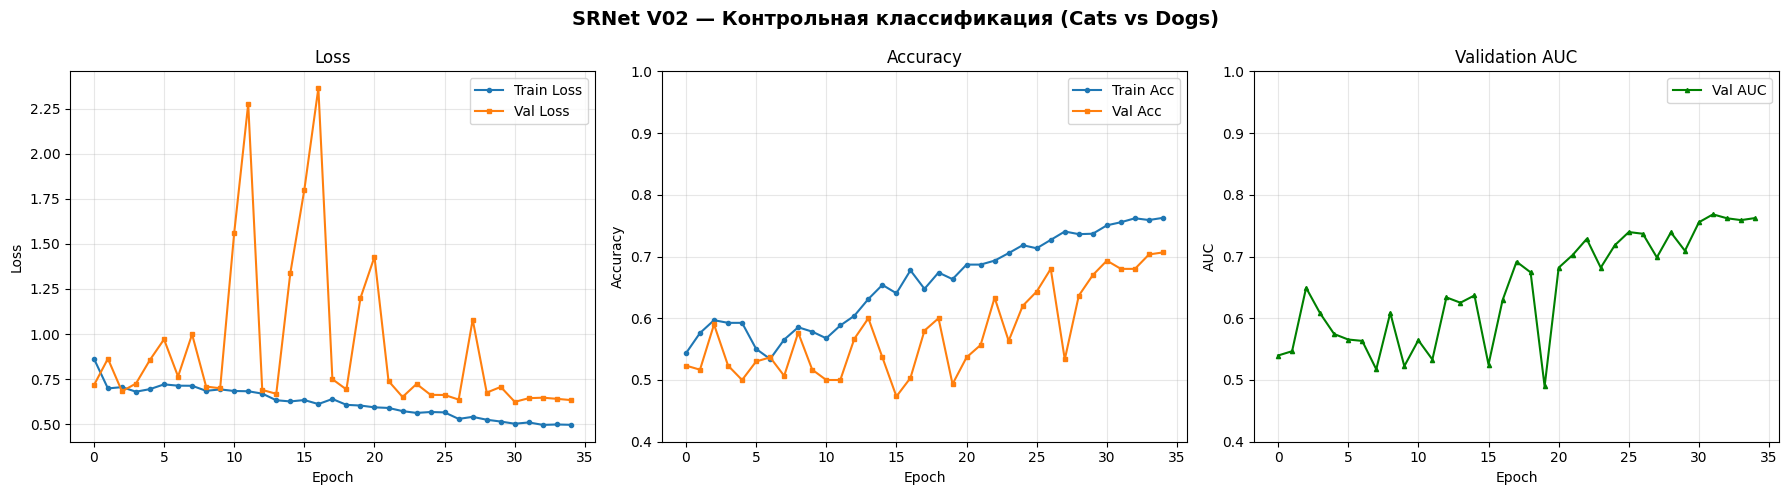

График: /content/drive/MyDrive/FQW/cat-dog_srnet_256_V02/srnet_v02_training_history.png


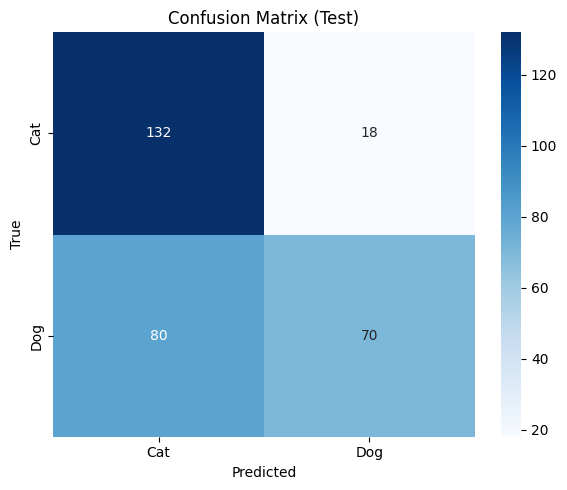

Матрица ошибок: /content/drive/MyDrive/FQW/cat-dog_srnet_256_V02/srnet_v02_confusion_matrix.png


In [10]:
# 9. Визуализация результатов

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SRNet V02 — Контрольная классификация (Cats vs Dogs)",
             fontsize=14, fontweight="bold")

axes[0].plot(history["train_loss"], label="Train Loss", marker="o", markersize=3)
axes[0].plot(history["val_loss"],   label="Val Loss",   marker="s", markersize=3)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="Train Acc", marker="o", markersize=3)
axes[1].plot(history["val_acc"],   label="Val Acc",   marker="s", markersize=3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.4, 1.0])

axes[2].plot(history["val_auc"], label="Val AUC", marker="^", markersize=3, color="green")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("AUC")
axes[2].set_title("Validation AUC"); axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0.4, 1.0])

plt.tight_layout()
history_path = os.path.join(SAVE_DIR, "srnet_v02_training_history.png")
plt.savefig(history_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"График: {history_path}")

fig2, ax2 = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Cat", "Dog"], yticklabels=["Cat", "Dog"], ax=ax2)
ax2.set_xlabel("Predicted"); ax2.set_ylabel("True")
ax2.set_title("Confusion Matrix (Test)")
plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, "srnet_v02_confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Матрица ошибок: {cm_path}")

In [11]:
# 10. Сохранение результатов

results = {
    "experiment": "SRNet V02 — контрольная классификация (Cats vs Dogs, grayscale 256)",
    "architecture": "SRNet (8 Type-I + 4 Type-II, Boroumand et al. 2019)",
    "dataset": {
        "name": "Cats-vs-Dogs-Gray-1000",
        "total": len(df),
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
        "split": "holdout 70/15/15",
    },
    "hyperparameters": {
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "scheduler": "CosineAnnealingLR(eta_min=1e-5)",
        "optimizer": "Adam",
        "loss": "CrossEntropyLoss",
        "dropout": "Dropout(0.3)",
        "grad_clip": 1.0,
        "augmentations": "HFlip(0.5), VFlip(0.5)",
        "hpf": "learnable (Kaiming init) + ReLU",
        "type1_blocks": 8,
        "type2_blocks": 4,
        "seed": SEED,
    },
    "trainable_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
    "best_epoch": best_epoch,
    "results": {
        "test_loss": round(test_loss, 4),
        "test_accuracy": round(test_acc, 4),
        "test_auc": round(test_auc, 4),
        "precision_cat": round(p_cat, 4),
        "recall_cat": round(r_cat, 4),
        "f1_cat": round(f1_cat, 4),
        "precision_dog": round(p_dog, 4),
        "recall_dog": round(r_dog, 4),
        "f1_dog": round(f1_dog, 4),
        "confusion_matrix": cm.tolist(),
    },
    "training_history": history,
    "version_history": {
        "V01": "72.33% / AUC 0.7983 (~20M, abs+tanh in blocks, no Type-I/II split)",
        "V02": f"{test_acc*100:.2f}% / AUC {test_auc:.4f} (proper Type-I/II, ReLU, Dropout)",
    },
}

json_path = os.path.join(SAVE_DIR, "srnet_v02_results.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f"Результаты: {json_path}")

print(f"\n{'='*60}")
print(f"ИТОГО: SRNet V02")
print(f"{'='*60}")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test AUC:      {test_auc:.4f}")
print(f"Лучшая эпоха:  {best_epoch}")
print(f"Параметров:    {results['trainable_parameters']:,}")
print(f"Сохранение:    {SAVE_DIR}")
print(f"{'='*60}")

Результаты: /content/drive/MyDrive/FQW/cat-dog_srnet_256_V02/srnet_v02_results.json

ИТОГО: SRNet V02
Test Accuracy: 67.33%
Test AUC:      0.7571
Лучшая эпоха:  32
Параметров:    10,400,706
Сохранение:    /content/drive/MyDrive/FQW/cat-dog_srnet_256_V02


## Результаты обучения

Модель достигла Test Accuracy = 67.33 % и ROC-AUC = 0.7571 при 10 400 706 обучаемых параметрах. Результат ниже V01 (72.33 % / AUC 0.7983), что объясняется архитектурной спецификой: 8 Type-I блоков в полном разрешении 256×256 обрабатывают карты размером 64×256×256 без пулинга, расходуя основную вычислительную ёмкость на сохранение пространственной информации. Для семантической задачи это невыгодно — высокоуровневые признаки формы и текстуры формируются эффективнее при раннем понижении разрешения, которое V01 применяла в каждой группе блоков.

Матрица ошибок [[132, 18], [80, 70]] демонстрирует наибольший перекос среди всех архитектур серии: Recall кошек — 88 % (132 из 150), Recall собак — 47 % (70 из 150). 80 собак ошибочно классифицированы как кошки. Асимметрия связана с тем, что Type-I блоки без пулинга сохраняют детальные пространственные паттерны, по которым модель хорошо выделяет кошек (более контрастные текстурные элементы), но не формирует достаточно абстрактных признаков для уверенного распознавания собак.

Динамика обучения показывает замедленную, но устойчивую сходимость: val AUC монотонно рос в последних 15 эпохах с 0.69 до 0.77, train accuracy достиг 76 %. Скачки val_loss (до 2.37 на эпохе 17) характерны для тяжёлых моделей на малых датасетах — gradient clipping ограничил их влияние на веса.

Сопоставление с остальными архитектурами серии 1:

| Архитектура | Test Accuracy | Test AUC | Параметры |
|---|---|---|---|
| Zhu-Net V02 | 74.00 % | 0.8346 | 531K |
| GSR-Net V04 | 68.33 % | 0.7369 | 11.5M |
| Yedroudj-Net V02 | 67.67 % | 0.7535 | 32K |
| SRNet V02 | 67.33 % | 0.7571 | 10.4M |

SRNet  расположилась в общем кластере 67–68 % вместе с GSR-Net и Yedroudj-Net, в то время как Zhu-Net уверенно лидирует.

Обучаемость архитектуры подтверждена: AUC = 0.7571 значительно выше случайного порога 0.50, модель устойчиво обучалась на протяжении 35 эпох.